In [4]:
import os
import glob
import json
import sys
import time
import requests
from datetime import datetime

import pandas as pd
import numpy as np
import rasterio
import rasterstats
import rioxarray as rxr
import geopandas as gpd
from osgeo import gdal
from shapely.geometry import box
from tqdm.notebook import tqdm_notebook as tqdm

In [5]:
dir = os.getcwd()

In [6]:
# df = pd.read_csv(os.path.join(dir, 'datasets/South_VNM_3per_sampleID.csv'))
df = pd.read_csv(os.path.join(dir, 'datasets\South_sample_5x10000.csv'))
df

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\sonle\AppData\Local\Temp\ipykernel_36436\445749686.py:2: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv(os.path.join(dir, 'datasets\South_sample_5x10000.csv'))


,id,lon,lat,sample_1,sample_2,sample_3,sample_4,sample_5
0,518582,105.34409,9.759747,0,0,0,0,1
1,306736,105.16891,10.705672,0,0,0,0,1
2,515851,105.34139,9.483066,0,0,0,0,1
3,398571,105.24168,10.394855,0,0,0,0,1
4,807982,105.56148,10.331973,0,0,0,0,1
...,...,...,...,...,...,...,...,...
49391,664345,105.46446,9.630389,0,0,0,1,0
49392,1527014,106.54154,10.091225,0,0,0,1,0
49393,967309,105.67736,9.376165,0,0,1,0,0
49394,578874,105.39799,10.594281,0,1,0,0,0


In [10]:
sample = df[df['sample_4'] == 1]
sample

,id,lon,lat,sample_1,sample_2,sample_3,sample_4,sample_5
267,948854,105.66389,9.595355,0,0,0,1,1
307,1429893,106.21365,10.983252,0,0,0,1,1
446,1192168,105.87229,9.810052,0,0,0,1,1
659,38861,104.74042,10.393957,0,0,0,1,1
791,1570086,106.65562,10.376889,0,0,0,1,1
...,...,...,...,...,...,...,...,...
49383,1102484,105.78786,10.845810,0,0,0,1,0
49389,626787,105.43751,10.224175,0,0,0,1,0
49390,107306,104.90302,9.078823,0,0,0,1,0
49391,664345,105.46446,9.630389,0,0,0,1,0


In [11]:
api_key = '73f784c939b7c0017b23be2e72b482cc'

lats = sample['lat'].to_list()
lons = sample['lon'].to_list()

def create_json(lat:str, lon:str, start: int, end: int) -> dict:
    hist_url = f'http://api.openweathermap.org/data/2.5/air_pollution/history?lat={lat}&lon={lon}&start={start}&end={end}&appid={api_key}'
    r = requests.get(hist_url)
    json_out = r.json()

    return json_out

for i in tqdm(range(len(lats))[:]):

    print(lats[i], lons[i])
    

    start_1 = int(time.mktime(datetime(2022, 1, 1).timetuple()))
    end_1 = int(time.mktime(datetime(2022, 12, 31).timetuple()))
   
    # Dumps json file
    json_1 = create_json(lats[i], lons[i], start_1, end_1)
    with open(f"datasets/owm/{lats[i]}_{lons[i]}_2022.json", "w") as outfile: 
        json.dump(json_1, outfile)




  0%|          | 0/10000 [00:00<?, ?it/s]

9.595355 105.66389
10.983252 106.21365
9.8100519 105.87229
10.393957 104.74042
10.376889 106.65562
10.463127 106.1885
11.771074 106.58286
10.156802 105.56328
10.610451 106.32145
9.7866955 105.5507
10.521518 105.96482
9.6079311 105.79324
10.564637 105.23718
9.9699526 105.21114
10.776639 105.66479
10.418212 104.63082
10.443364 106.63227
9.9169512 105.37373
10.608654 106.28282
9.9007816 105.47973
9.723814 105.15903
9.8432894 105.41955
10.841318 105.24976
10.611349 106.42297
10.940133 105.56687
10.72274 105.68365
10.835928 105.87679
10.304126 104.64789
9.8289165 105.73575
10.590688 105.07639
10.319397 105.12669
10.485585 105.15903
10.29065 105.07639
10.425398 106.16515
10.741605 106.15527
9.8702393 105.51836
10.14692 105.07279
10.409228 105.3899
9.921443 105.97919
9.8540697 105.30546
10.730825 106.15437
9.8298149 105.5525
10.035529 105.91991
10.712859 105.48153
9.7274075 105.80492
10.182853 105.05393
9.5010319 105.68814
10.735317 106.17413
10.644587 105.29917
10.546671 105.68185
10.442466 

In [14]:
sample = df[df['sample_5'] == 1]

lats = sample['lat'].to_list()
lons = sample['lon'].to_list()

def create_json(lat:str, lon:str, start: int, end: int) -> dict:
    hist_url = f'http://api.openweathermap.org/data/2.5/air_pollution/history?lat={lat}&lon={lon}&start={start}&end={end}&appid={api_key}'
    r = requests.get(hist_url)
    json_out = r.json()

    return json_out

for i in tqdm(range(len(lats))[1262+1718:]):

    print(lats[i], lons[i])
    

    start_1 = int(time.mktime(datetime(2022, 1, 1).timetuple()))
    end_1 = int(time.mktime(datetime(2022, 12, 31).timetuple()))
   
    # Dumps json file
    json_1 = create_json(lats[i], lons[i], start_1, end_1)
    with open(f"datasets/owm/{lats[i]}_{lons[i]}_2022.json", "w") as outfile: 
        json.dump(json_1, outfile)

  0%|          | 0/7020 [00:00<?, ?it/s]

10.522416 105.87948
10.127157 105.64053
10.798199 105.50039
10.25921 105.02338
10.804487 105.65401
10.142428 105.29648
10.171175 105.02788
10.396652 106.0304
10.734419 105.98997
9.0321112 105.24707
10.56284 105.55968
10.132547 105.89116
10.012173 105.41775
10.630214 105.63963
10.826945 105.64682
9.2288418 104.83295
10.783826 105.97381
9.7759161 105.88667
9.1839266 105.19138
10.773046 105.91631
10.002292 105.46356
10.890725 105.22192
10.923963 105.51656
9.5046253 105.73215
10.3176 106.69246
11.972297 106.59903
10.078649 105.54172
10.821555 105.24707
9.9933081 105.49321
9.2629776 105.21114
10.66435 105.09525
10.303227 104.99194
9.8909006 105.2857
10.475703 105.66927
9.5387611 105.55878
10.356228 105.09166
10.458635 105.22551
10.218785 105.47344
10.851199 105.68095
10.046309 105.62616
10.620333 105.98997
10.692198 105.59113
9.1821299 104.92368
10.165785 105.1231
10.571823 106.16695
10.423601 106.16784
9.4381495 105.57585
9.2737579 105.57585
10.300532 105.2803
9.4309626 105.52285
10.260108

In [44]:
with open('JAXA_subtiles.json', 'r') as json_file:
    jaxa_subtiles = json.load(json_file)

tiles = list(jaxa_subtiles.keys())[1:16]
tiles.extend(list(jaxa_subtiles.keys())[33:])

bbox = [jaxa_subtiles[tile] for tile in tiles]

bbox = [box(tile[0], tile[1], tile[2], tile[3]) for tile in bbox]

tiles_gdf = gpd.GeoDataFrame({'tile': tiles, 
                              'geometry': bbox})
tiles_gdf = tiles_gdf.set_crs(epsg=4326)
tiles_gdf.head()
tiles_gdf.to_file('chosen_tiles.json', driver='GeoJSON', index=False)

In [35]:
tiles_gdf.crs

In [38]:
dist_gdf = gpd.read_file('gadm41_VNM_2.json')
dist_gdf = dist_gdf.to_crs(tiles_gdf.crs)
dist_gdf.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,VNM.1.1_1,VNM,Vietnam,VNM.1_1,AnGiang,NA,AnPhú,AnPhu,NA,Huyện,District,NA,VN.TT.AL,"MULTIPOLYGON (((105.15660 10.82870, 105.16010 ..."
1,VNM.1.3_1,VNM,Vietnam,VNM.1_1,AnGiang,NA,ChâuĐốc,ChauDoc,NA,Thànhphố,City,NA,VN.KG.AB,"MULTIPOLYGON (((105.10500 10.63830, 105.08150 ..."
2,VNM.1.4_1,VNM,Vietnam,VNM.1_1,AnGiang,NA,ChâuPhú,ChauPhu,NA,Huyện,District,NA,VN.HP.AD,"MULTIPOLYGON (((105.18790 10.46030, 105.17980 ..."
3,VNM.1.5_1,VNM,Vietnam,VNM.1_1,AnGiang,NA,ChâuThành,ChauThanh,NA,Huyện,District,NA,VN.GL.AK,"MULTIPOLYGON (((105.37090 10.36220, 105.36820 ..."
4,VNM.1.2_1,VNM,Vietnam,VNM.1_1,AnGiang,NA,ChợMới,ChoMoi,NA,Huyện,District,NA,VN.BD.AL,"MULTIPOLYGON (((105.48720 10.53950, 105.48840 ..."


In [78]:
dist_geom = [geom for geom in dist_gdf.geometry]

intersects_geom = []
for geom in dist_geom:
    gdf = tiles_gdf.iloc[tiles_gdf.sindex.query(geom, predicate='intersects')]
    if len(gdf) > 0:
        intersects_geom.append(geom)

In [98]:
intersects_geom = list(set(intersects_geom))
dist_filtered = dist_gdf[dist_gdf.geometry.isin(intersects_geom)]

In [99]:
dist_filtered['lon'] = dist_filtered.centroid.x
dist_filtered['lat'] = dist_filtered.centroid.y
dist_filtered = dist_filtered[['GID_2', 'lat', 'lon']]
dist_dict = dist_filtered.set_index('GID_2').to_dict('index')
dist_dict

C:\Users\sonle\AppData\Local\Temp\ipykernel_28392\439494382.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  dist_filtered['lon'] = dist_filtered.centroid.x
c:\Users\sonle\anaconda3\envs\geospatial\Lib\site-packages\geopandas\geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\sonle\AppData\Local\Temp\ipykernel_28392\439494382.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  dist_filtered['lat'] = dist_filte

{'VNM.1.1_1': {'lat': 10.846404435922919, 'lon': 105.10074651097067},
 'VNM.1.3_1': {'lat': 10.674122054506455, 'lon': 105.08741946173457},
 'VNM.1.4_1': {'lat': 10.557603596145857, 'lon': 105.1797822230923},
 'VNM.1.5_1': {'lat': 10.421303385083814, 'lon': 105.26575383802694},
 'VNM.1.2_1': {'lat': 10.474944476027188, 'lon': 105.46144105444661},
 'VNM.1.6_1': {'lat': 10.371310030995655, 'lon': 105.42804673733518},
 'VNM.1.7_1': {'lat': 10.654870714342247, 'lon': 105.2757414511293},
 'VNM.1.9_1': {'lat': 10.800174081298888, 'lon': 105.18645918433309},
 'VNM.1.10_1': {'lat': 10.29683597866068, 'lon': 105.25556484274274},
 'VNM.1.8_1': {'lat': 10.547266352717338, 'lon': 105.01170710864969},
 'VNM.1.11_1': {'lat': 10.412558176021932, 'lon': 104.95909074038255},
 'VNM.7.5_1': {'lat': 10.5767716473971, 'lon': 107.08808543963191},
 'VNM.3.1_1': {'lat': 21.27452053546984, 'lon': 106.19658531724376},
 'VNM.3.2_1': {'lat': 21.324537974828658, 'lon': 105.96767319204977},
 'VNM.3.3_1': {'lat': 21

In [126]:
list(dist_dict.keys()).index('VNM.44.10_1')

290

In [127]:
list(dist_dict.keys())[290:]

['VNM.44.10_1',
 'VNM.44.11_1',
 'VNM.44.12_1',
 'VNM.44.13_1',
 'VNM.46.8_1',
 'VNM.49.1_1',
 'VNM.49.2_1',
 'VNM.49.3_1',
 'VNM.49.4_1',
 'VNM.49.5_1',
 'VNM.49.6_1',
 'VNM.49.7_1',
 'VNM.49.8_1',
 'VNM.49.9_1',
 'VNM.49.10_1',
 'VNM.49.11_1',
 'VNM.49.12_1',
 'VNM.49.13_1',
 'VNM.49.14_1',
 'VNM.51.1_1',
 'VNM.51.3_1',
 'VNM.51.4_1',
 'VNM.51.5_1',
 'VNM.51.6_1',
 'VNM.51.7_1',
 'VNM.51.8_1',
 'VNM.51.9_1',
 'VNM.51.10_1',
 'VNM.51.11_1',
 'VNM.53.9_1',
 'VNM.55.1_1',
 'VNM.55.2_1',
 'VNM.55.3_1',
 'VNM.55.4_1',
 'VNM.55.5_1',
 'VNM.55.6_1',
 'VNM.55.7_1',
 'VNM.55.8_1',
 'VNM.56.1_1',
 'VNM.56.2_1',
 'VNM.56.3_1',
 'VNM.56.4_1',
 'VNM.56.5_1',
 'VNM.56.6_1',
 'VNM.56.7_1',
 'VNM.56.8_1',
 'VNM.56.9_1',
 'VNM.57.2_1',
 'VNM.57.1_1',
 'VNM.57.3_1',
 'VNM.57.4_1',
 'VNM.57.6_1',
 'VNM.57.5_1',
 'VNM.57.7_1',
 'VNM.57.8_1',
 'VNM.57.11_1',
 'VNM.57.10_1',
 'VNM.57.12_1',
 'VNM.57.13_1',
 'VNM.57.14_1',
 'VNM.57.16_1',
 'VNM.57.17_1',
 'VNM.57.15_1',
 'VNM.57.18_1',
 'VNM.57.19_1',
 'VN

In [128]:
api_key = 'ac31e02046794bd3f959fbc98fc25231'

def create_json(location_name:str, start: int, end: int) -> dict:
    global dist_dict
    lat = dist_dict[location_name]['lat']
    lon = dist_dict[location_name]['lon']
    hist_url = f'http://api.openweathermap.org/data/2.5/air_pollution/history?lat={lat}&lon={lon}&start={start}&end={end}&appid={api_key}'
    r = requests.get(hist_url)
    json_out = r.json()
    json_out['name'] = location_name

    return json_out

for location_name in list(dist_dict.keys())[290:]:

    print(location_name)
    
    # 6 month extraction to avoid request timeout from OWM
    # loc_dict = {}

    for year in list(range(2018, 2023, 1)):
        print('     ', year)
        # January - June 
        start_1 = int(time.mktime(datetime(year, 1, 1).timetuple()))
        end_1 = int(time.mktime(datetime(year, 6, 30).timetuple()))

        # Dumps json file
        json_1 = create_json(location_name, start_1, end_1)
        with open(f"owm_pollution/HN_{location_name}_16_{year}.json", "w") as outfile: 
            json.dump(json_1, outfile)

        # July - December 
        start_2 = int(time.mktime(datetime(year, 7, 1).timetuple()))
        end_2 = int(time.mktime(datetime(year, 12, 31).timetuple()))

        # Dumps json file
        json_2 = create_json(location_name, start_2, end_2)
        with open(f"owm_pollution/HN_{location_name}_712_{year}.json", "w") as outfile: 
            json.dump(json_2, outfile)

        # full_json = json_1 | json_2
    
    # loc_dict.update(full_json)



VNM.44.10_1
      2018
      2019
      2020
      2021
      2022
VNM.44.11_1
      2018
      2019
      2020
      2021
      2022
VNM.44.12_1
      2018
      2019
      2020
      2021
      2022
VNM.44.13_1
      2018
      2019
      2020
      2021
      2022
VNM.46.8_1
      2018
      2019
      2020
      2021
      2022
VNM.49.1_1
      2018
      2019
      2020
      2021
      2022
VNM.49.2_1
      2018
      2019
      2020
      2021
      2022
VNM.49.3_1
      2018
      2019
      2020
      2021
      2022
VNM.49.4_1
      2018
      2019
      2020
      2021
      2022
VNM.49.5_1
      2018
      2019
      2020
      2021
      2022
VNM.49.6_1
      2018
      2019
      2020
      2021
      2022
VNM.49.7_1
      2018
      2019
      2020
      2021
      2022
VNM.49.8_1
      2018
      2019
      2020
      2021
      2022
VNM.49.9_1
      2018
      2019
      2020
      2021
      2022
VNM.49.10_1
      2018
      2019
      2020
      2021
      2022
VNM.4

In [7]:
paths = glob.glob('D:\Work\ADB\SAR\datasets\owm/*.json')
paths.sort()
paths

<>:1: SyntaxWarning: invalid escape sequence '\W'
<>:1: SyntaxWarning: invalid escape sequence '\W'
C:\Users\sonle\AppData\Local\Temp\ipykernel_36436\440931412.py:1: SyntaxWarning: invalid escape sequence '\W'
  paths = glob.glob('D:\Work\ADB\SAR\datasets\owm/*.json')


['D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.10064_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.13927_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.14197_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.15185_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.18778_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.19856_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.2309_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.24258_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.25874_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.30186_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.31893_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.34678_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.34768_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm\\10.000495_105.35307_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets\\owm

In [8]:
dfs = []

for path in tqdm(paths):
    with open(path, 'r') as f:
        d = json.load(f)
    dates = []
    pm25s = []

    for i in range(len(d['list'])):
        dates.append(d['list'][i]['dt'])
        pm25s.append(d['list'][i]['components']['pm2_5'])


    lat_l = path.rindex('\\')
    lat_r = path.index('_')
    lon_r = path.rindex('_')

    df_p = pd.DataFrame({'lat': path[lat_l+1:lat_r],
                        'lon': path[lat_r+1:lon_r],
                        'dt': dates,
                        'pm25': pm25s})
    df_p['dt'] = pd.to_datetime(df_p['dt'], unit='s')
    df_p['dt'] = df_p['dt'].dt.tz_localize('UTC').dt.tz_convert('Asia/Saigon')
    df_p['month'] = df_p['dt'].dt.month
    df_p = df_p.groupby(['lat', 'lon', 'month']).agg({'pm25': 'mean'}).reset_index()

    df_p['lat'] = df_p['lat'].astype('float64')
    df_p['lon'] = df_p['lon'].astype('float64')

    dfs.append(df_p)

  0%|          | 0/95911 [00:00<?, ?it/s]

In [9]:
df_all = pd.concat(dfs, axis=0).reset_index(drop=True)
df_all

,lat,lon,month,pm25
0,10.000495,105.10064,1,30.825722
1,10.000495,105.10064,2,24.829599
2,10.000495,105.10064,3,25.805780
3,10.000495,105.10064,4,35.481083
4,10.000495,105.10064,5,15.307204
...,...,...,...,...
1150927,9.999597,105.98009,8,30.194556
1150928,9.999597,105.98009,9,21.298597
1150929,9.999597,105.98009,10,56.314220
1150930,9.999597,105.98009,11,42.334556


In [11]:
df

,id,lon,lat,sample_1,sample_2,sample_3,sample_4,sample_5
0,518582,105.34409,9.759747,0,0,0,0,1
1,306736,105.16891,10.705672,0,0,0,0,1
2,515851,105.34139,9.483066,0,0,0,0,1
3,398571,105.24168,10.394855,0,0,0,0,1
4,807982,105.56148,10.331973,0,0,0,0,1
...,...,...,...,...,...,...,...,...
49391,664345,105.46446,9.630389,0,0,0,1,0
49392,1527014,106.54154,10.091225,0,0,0,1,0
49393,967309,105.67736,9.376165,0,0,1,0,0
49394,578874,105.39799,10.594281,0,1,0,0,0


In [12]:
df_out = pd.merge(df, df_all, on=['lat', 'lon'], how='inner')
df_out

,id,lon,lat,sample_1,sample_2,sample_3,sample_4,sample_5,month,pm25
0,518582,105.34409,9.759747,0,0,0,0,1,1,23.142625
1,518582,105.34409,9.759747,0,0,0,0,1,2,19.527114
2,518582,105.34409,9.759747,0,0,0,0,1,3,22.524194
3,518582,105.34409,9.759747,0,0,0,0,1,4,33.457819
4,518582,105.34409,9.759747,0,0,0,0,1,5,17.502218
...,...,...,...,...,...,...,...,...,...,...
592747,1438174,106.23431,10.621231,0,0,1,0,0,8,22.739489
592748,1438174,106.23431,10.621231,0,0,1,0,0,9,21.350389
592749,1438174,106.23431,10.621231,0,0,1,0,0,10,36.954409
592750,1438174,106.23431,10.621231,0,0,1,0,0,11,44.703403


In [13]:
df_out.to_csv('datasets/owm_pm25_2022_2nd_batch.csv', index=False)

In [24]:
import geopandas as gpd

gdf = gpd.read_file(r"C:\Users\sonle\Downloads\rou_adm_ancpi_v02_20220427_ab_shp\rou_adm_ancpi_v02_20220427_AB_SHP\rou_admbnda_adm2_ancpi_v02_20220427.shp")
gdf.head()

,Shape_Leng,Shape_Area,ADM2_RO,ADM2_PCODE,ADM2_REF,ADM2ALT1RO,ADM2ALT2RO,ADM1_RO,ADM1_PCODE,ADM0_EN,ADM0_RO,ADM0_PCODE,date,validOn,validTo,geometry
0,6.558193,0.775128,Bacău,RO001047,Bacau,None,None,Nord-Est,RO001,Romania,România,RO,2022-03-09,2022-04-27,None,"POLYGON ((27.20620 46.76990, 27.20660 46.76950..."
1,5.637132,0.599211,Botoșani,RO001074,Botosani,None,None,Nord-Est,RO001,Romania,România,RO,2022-03-09,2022-04-27,None,"POLYGON ((27.39140 47.58950, 27.39050 47.58900..."
2,8.258205,0.650137,Iași,RO001225,Iasi,None,None,Nord-Est,RO001,Romania,România,RO,2022-03-09,2022-04-27,None,"POLYGON ((28.11470 46.83760, 28.11390 46.83780..."
3,6.423956,0.697207,Neamț,RO001270,Neamt,None,None,Nord-Est,RO001,Romania,România,RO,2022-03-09,2022-04-27,None,"POLYGON ((27.20620 46.76990, 27.20530 46.76910..."
4,7.199228,1.022137,Suceava,RO001332,None,None,None,Nord-Est,RO001,Romania,România,RO,2022-03-09,2022-04-27,None,"POLYGON ((26.09880 47.97880, 26.09860 47.97840..."


In [25]:
gdf_2 = gpd.read_file(r"C:\Users\sonle\Downloads\gadm41_ROU_2.json")
gdf_1 = gpd.read_file(r"C:\Users\sonle\Downloads\gadm41_ROU_1.json")

In [130]:
mun = gdf_2[(gdf_2['VARNAME_2'].str.contains('Municipiul')) | (gdf_2['NAME_2'].str.contains('Municipiul'))]
mun['NAME_2'] = mun['NAME_2'].str.replace('Municipiul', '')
mun['VARNAME_2'] = mun['VARNAME_2'].str.replace('NA', 'Bucuresti')
mun['VARNAME_2'] = mun['VARNAME_2'].str.replace('Municipiul', '')
mun['VARNAME_2'] = mun['VARNAME_2'].str.replace(r'(?<=[a-z])(?=[A-Z])', ' ', regex=True)
mun['VARNAME_2'] = mun['VARNAME_2'].str.replace('-', '')
mun['mun_code'] = mun['VARNAME_2'].str[:10]
mun['mun_code'] = mun['mun_code'].str.lower()
mun

c:\Users\sonle\anaconda3\envs\geospatial\Lib\site-packages\geopandas\geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\sonle\anaconda3\envs\geospatial\Lib\site-packages\geopandas\geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,mun_code
1,ROU.1.2_1,ROU,Romania,ROU.1_1,Alba,NA,Aiud,Aiud,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((23.59480 46.33810, 23.60300 46...",aiud
2,ROU.1.3_1,ROU,Romania,ROU.1_1,Alba,NA,AlbaIulia,Alba Iulia,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((23.62130 46.11340, 23.61860 46...",alba iulia
10,ROU.1.11_1,ROU,Romania,ROU.1_1,Alba,NA,Blaj,Blaj,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((24.03720 46.10240, 24.03080 46...",blaj
62,ROU.1.63_1,ROU,Romania,ROU.1_1,Alba,NA,Sebes,Sebes,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((23.54470 46.02510, 23.55310 46...",sebes
78,ROU.2.3_1,ROU,Romania,ROU.2_1,Arad,NA,Arad,Arad,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((21.36720 46.14600, 21.35840 46...",arad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2807,ROU.41.8_1,ROU,Romania,ROU.41_1,Vaslui,NA,Barlad,Barlad,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((27.69050 46.21470, 27.68940 46...",barlad
2834,ROU.41.35_1,ROU,Romania,ROU.41_1,Vaslui,NA,Husi,Husi,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((28.04770 46.64680, 28.04640 46...",husi
2866,ROU.41.67_1,ROU,Romania,ROU.41_1,Vaslui,NA,Vaslui,Vaslui,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((27.66480 46.65040, 27.66510 46...",vaslui
2875,ROU.42.1_1,ROU,Romania,ROU.42_1,Vrancea,NA,Adjud,Adjud,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((27.12880 46.13810, 27.12660 46...",adjud


In [132]:
mun[mun['NAME_2'].str.contains('Bucuresti')]

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,mun_code
655,ROU.10.1_1,ROU,Romania,ROU.10_1,Bucharest,NA,Bucuresti,Bucuresti,NA,Comune,Municipality,NA,NA,"MULTIPOLYGON (((26.16710 44.34350, 26.15570 44...",bucuresti


In [38]:
[c for c in gdf_1['NAME_1'].unique() if c not in mun['NAME_1'].unique()]

['Bucharest', 'Ilfov']

In [110]:
gdf_2[gdf_2['NAME_1'] == 'Ilfov']

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
1675,ROU.26.1_1,ROU,Romania,ROU.26_1,Ilfov,NA,1Decembrie,NA,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((26.12040 44.24510, 26.10740 44..."
1676,ROU.26.2_1,ROU,Romania,ROU.26_1,Ilfov,NA,Afumati,NA,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((26.23790 44.58580, 26.27020 44..."
1677,ROU.26.3_1,ROU,Romania,ROU.26_1,Ilfov,NA,Balotesti,NA,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((26.07170 44.58540, 26.07200 44..."
1678,ROU.26.4_1,ROU,Romania,ROU.26_1,Ilfov,NA,Berceni,NA,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((26.15480 44.33600, 26.15650 44..."
1679,ROU.26.5_1,ROU,Romania,ROU.26_1,Ilfov,NA,Bragadiru,OrasBragadiru,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((25.97660 44.40750, 25.99430 44..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1709,ROU.26.35_1,ROU,Romania,ROU.26_1,Ilfov,NA,Snagov,NA,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((26.13410 44.64050, 26.12740 44..."
1710,ROU.26.36_1,ROU,Romania,ROU.26_1,Ilfov,NA,StefanestiiDeJos,NA,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((26.23790 44.58580, 26.22050 44..."
1711,ROU.26.37_1,ROU,Romania,ROU.26_1,Ilfov,NA,Tunari,NA,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((26.11660 44.59440, 26.14030 44..."
1712,ROU.26.38_1,ROU,Romania,ROU.26_1,Ilfov,NA,Vidra,NA,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((26.14040 44.33720, 26.14560 44..."


In [97]:
import pandas as pd
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 10)

In [133]:

scores = pd.read_excel(r"C:\Users\sonle\Downloads\for maps.xlsx", header=0)
scores = scores.iloc[1:]
scores['mun_code'] = scores['Municipality']
scores['mun_code'] = scores['mun_code'].str.replace('-', '')
scores['mun_code'] = scores['mun_code'].str[:10]
scores['mun_code'] = scores['mun_code'].str.lower()
# scores

In [134]:
merged_gdf = pd.merge(mun, scores, on=['mun_code'], how='left').drop_duplicates(subset=['GID_2'])
merged_gdf

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,mun_code,Municipality,Count,Transparency score,AVERAGEMUNICIP_ind_corr_nocft,AVERAGEMUNICIP_ind_corr_singleb,AVERAGEMUNICIP_ind_corr_dec_period,AVERAGEMUNICIP_ind_corr_nonopen_proc_method,AVERAGEMUNICIP_ind_corr_subm_period,AVERAGEMUNICIP_ind_corr_benfords,AVERAGEMUNICIP_ind_winner_share,AVERAGEMUNICIP_ind_corr_delay
0,ROU.1.2_1,ROU,Romania,ROU.1_1,Alba,NA,Aiud,Aiud,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((23.59480 46.33810, 23.60300 46...",aiud,AIUD,610.0,87.562,100.0,73.134,57.836,60.448,9.524,NaN,87.099,97.761
1,ROU.1.3_1,ROU,Romania,ROU.1_1,Alba,NA,AlbaIulia,Alba Iulia,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((23.62130 46.11340, 23.61860 46...",alba iulia,ALBA IULIA,3693.0,87.941,100.0,68.601,57.679,62.799,54.348,100.0,90.542,96.928
2,ROU.1.11_1,ROU,Romania,ROU.1_1,Alba,NA,Blaj,Blaj,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((24.03720 46.10240, 24.03080 46...",blaj,BLAJ,736.0,87.263,100.0,64.979,67.510,78.112,15.274,100.0,87.726,99.179
3,ROU.1.63_1,ROU,Romania,ROU.1_1,Alba,NA,Sebes,Sebes,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((23.54470 46.02510, 23.55310 46...",sebes,SEBES,651.0,84.570,100.0,72.958,79.014,87.183,99.522,100.0,88.301,99.437
4,ROU.2.3_1,ROU,Romania,ROU.2_1,Arad,NA,Arad,Arad,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((21.36720 46.14600, 21.35840 46...",arad,ARAD,7107.0,87.884,100.0,52.786,51.857,48.981,85.714,100.0,95.092,97.364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,ROU.41.8_1,ROU,Romania,ROU.41_1,Vaslui,NA,Barlad,Barlad,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((27.69050 46.21470, 27.68940 46...",barlad,BARLAD,1589.0,82.383,100.0,78.570,56.150,65.990,94.070,100.0,94.750,90.200
99,ROU.41.35_1,ROU,Romania,ROU.41_1,Vaslui,NA,Husi,Husi,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((28.04770 46.64680, 28.04640 46...",husi,HUSI,536.0,87.810,100.0,79.610,53.590,68.250,47.620,100.0,87.430,99.610
100,ROU.41.67_1,ROU,Romania,ROU.41_1,Vaslui,NA,Vaslui,Vaslui,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((27.66480 46.65040, 27.66510 46...",vaslui,VASLUI,3213.0,87.986,100.0,68.700,54.470,67.070,37.500,100.0,90.980,98.370
101,ROU.42.1_1,ROU,Romania,ROU.42_1,Vrancea,NA,Adjud,Adjud,NA,Comune,Commune,NA,NA,"MULTIPOLYGON (((27.12880 46.13810, 27.12660 46...",adjud,ADJUD,167.0,88.550,100.0,79.880,52.440,56.100,100.000,NaN,86.800,98.170


In [187]:
import numpy as np
merged_gdf['test'] = np.where(merged_gdf['AVERAGEMUNICIP_ind_corr_singleb'] <= 60, 'red',
                              np.where(merged_gdf['AVERAGEMUNICIP_ind_corr_singleb'] <= 70, 'orange', 
                                       np.where(merged_gdf['AVERAGEMUNICIP_ind_corr_singleb'] <= 80, 'yellow', 
                                                np.where(merged_gdf['AVERAGEMUNICIP_ind_corr_singleb'] <= 90, 'blue', 'green'))))

merged_gdf['test'].value_counts()

test
orange    30
yellow    26
red       25
blue      19
green      3
Name: count, dtype: int64

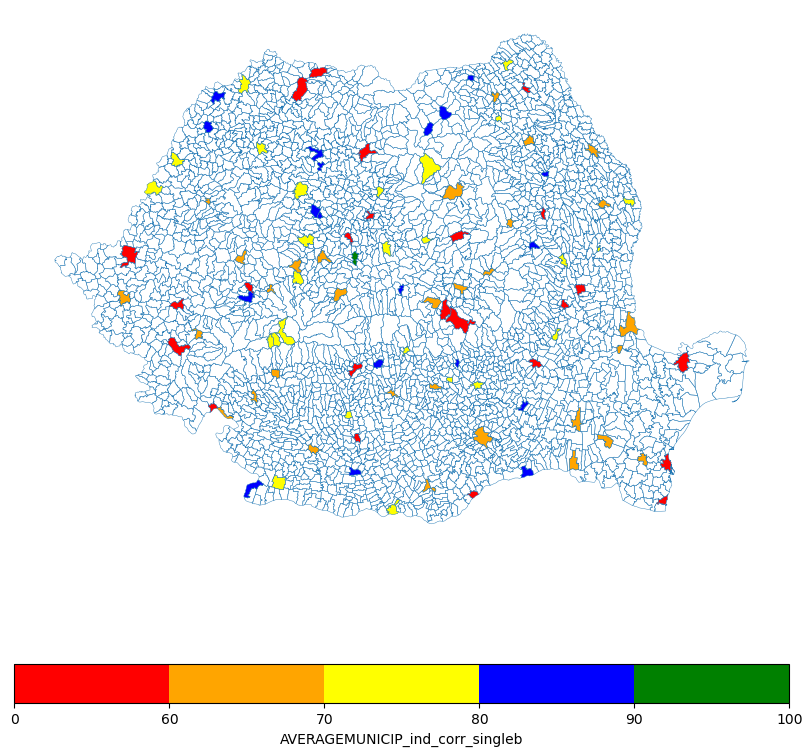

In [188]:
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors

colors = ['red', 'orange', 'yellow', 'blue', 'green']
boundaries = [0, 60, 70, 80, 90, 100]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf_2.boundary.plot(ax=ax, linewidth=0.3)
merged_gdf.plot(column='AVERAGEMUNICIP_ind_corr_singleb',  ax=ax, cmap=cmap, norm=norm)
ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # No data for colorbar
cbar = fig.colorbar(sm, ax=ax, ticks=boundaries, orientation='horizontal')
cbar.set_label('AVERAGEMUNICIP_ind_corr_singleb')

In [162]:
columns = ['GID_1'] + scores.columns.to_list()
columns

['GID_1',
 'Municipality',
 'Count',
 'Transparency score',
 'AVERAGEMUNICIP_ind_corr_nocft',
 'AVERAGEMUNICIP_ind_corr_singleb',
 'AVERAGEMUNICIP_ind_corr_dec_period',
 'AVERAGEMUNICIP_ind_corr_nonopen_proc_method',
 'AVERAGEMUNICIP_ind_corr_subm_period',
 'AVERAGEMUNICIP_ind_corr_benfords',
 'AVERAGEMUNICIP_ind_winner_share',
 'AVERAGEMUNICIP_ind_corr_delay',
 'mun_code']

In [181]:
gb_2 = merged_gdf[columns].groupby(['GID_1']).agg({'AVERAGEMUNICIP_ind_corr_singleb': 'mean',
                                                   'AVERAGEMUNICIP_ind_corr_dec_period': 'mean',
                                                   'AVERAGEMUNICIP_ind_corr_benfords': 'mean'}).reset_index()


merged_1 = gpd.GeoDataFrame(pd.merge(gb_2, gdf_1, on=['GID_1'], how='left'))
merged_1

,GID_1,AVERAGEMUNICIP_ind_corr_singleb,AVERAGEMUNICIP_ind_corr_dec_period,AVERAGEMUNICIP_ind_corr_benfords,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,ROU.10_1,63.4900,63.01000,93.730000,ROU,Romania,Bucharest,Bucuresti,NA,Municipiu,Municipality,NA,RO.BI,NA,"MULTIPOLYGON (((26.16710 44.34350, 26.15570 44..."
1,ROU.11_1,61.7540,63.74550,NaN,ROU,Romania,Buzău,Buzau,NA,Judet,County,NA,RO.BZ,NA,"MULTIPOLYGON (((27.22290 44.86100, 27.23290 44..."
2,ROU.12_1,72.9120,56.03500,0.000000,ROU,Romania,Călărași,Calarasi,NA,Judet,County,NA,RO.CL,NA,"MULTIPOLYGON (((26.76970 44.07970, 26.72520 44..."
3,ROU.13_1,63.0205,52.91200,100.000000,ROU,Romania,Caraș-Severin,Caras-severin,NA,Judet,County,NA,RO.CS,NA,"MULTIPOLYGON (((22.15000 44.69540, 22.14740 44..."
4,ROU.14_1,81.6622,64.52060,74.797667,ROU,Romania,Cluj,NA,NA,Judet,County,NA,RO.CJ,RO-CJ,"MULTIPOLYGON (((23.97250 46.43530, 23.97460 46..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36,ROU.5_1,74.7010,53.40350,66.666667,ROU,Romania,Bihor,NA,NA,Judet,County,NA,RO.BH,RO-BH,"MULTIPOLYGON (((22.68070 46.46850, 22.68540 46..."
37,ROU.6_1,54.9020,52.05000,100.000000,ROU,Romania,Bistrița-Năsăud,Bistrita-nasaud,NA,Judet,County,NA,RO.BN,NA,"MULTIPOLYGON (((24.46250 46.81500, 24.46490 46..."
38,ROU.7_1,62.1350,52.27850,100.000000,ROU,Romania,Botoșani,Botosani,NA,Judet,County,NA,RO.BT,NA,"MULTIPOLYGON (((27.08300 47.47340, 27.07930 47..."
39,ROU.8_1,62.2120,58.46375,42.802500,ROU,Romania,Brașov,Brasov,NA,Judet,County,NA,RO.BV,NA,"MULTIPOLYGON (((25.83830 45.72300, 25.83740 45..."


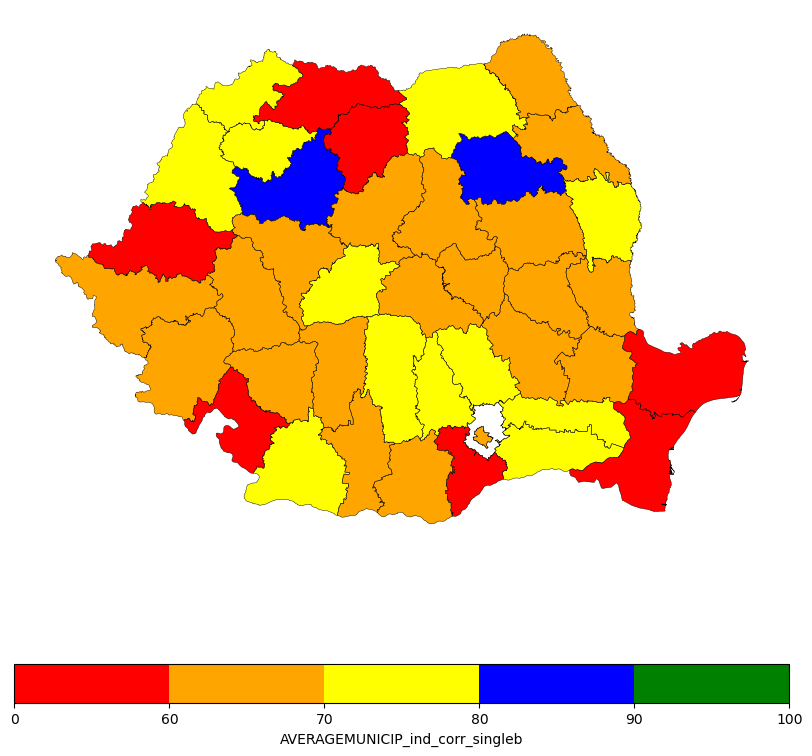

In [ ]:
colors = ['red', 'orange', 'yellow', 'blue', 'green']
boundaries = [0, 60, 70, 80, 90, 100]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf_1.boundary.plot(ax=ax, linewidth=0.3, color='black')
merged_1.plot(column='AVERAGEMUNICIP_ind_corr_singleb',  ax=ax, cmap=cmap, norm=norm)
ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # No data for colorbar
cbar = fig.colorbar(sm, ax=ax, ticks=boundaries, orientation='horizontal')
cbar.set_label('AVERAGEMUNICIP_ind_corr_singleb')

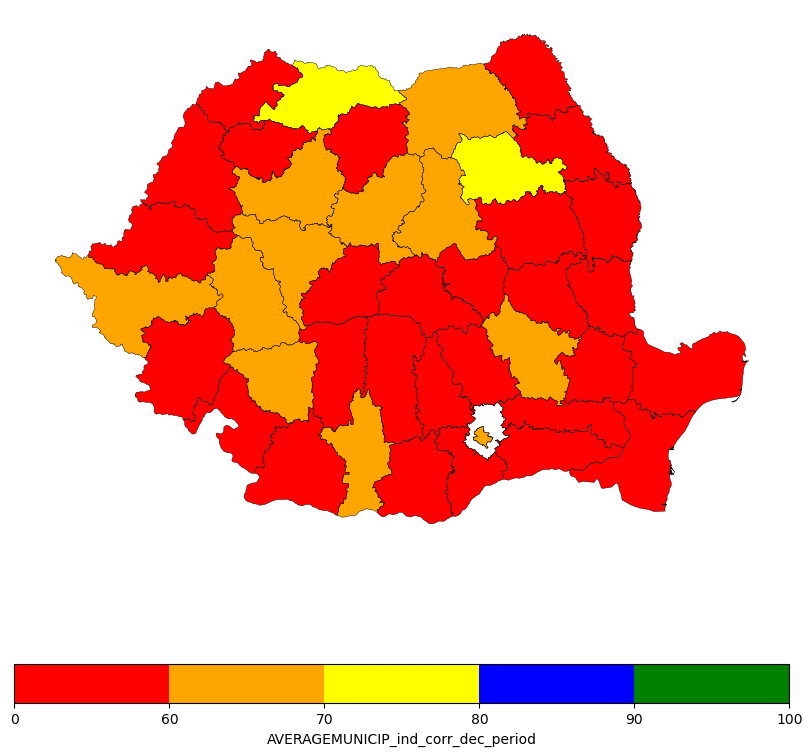

In [182]:
colors = ['red', 'orange', 'yellow', 'blue', 'green']
boundaries = [0, 60, 70, 80, 90, 100]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf_1.boundary.plot(ax=ax, linewidth=0.3, color='black')
merged_1.plot(column='AVERAGEMUNICIP_ind_corr_dec_period',  ax=ax, cmap=cmap, norm=norm)
ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # No data for colorbar
cbar = fig.colorbar(sm, ax=ax, ticks=boundaries, orientation='horizontal')
cbar.set_label('AVERAGEMUNICIP_ind_corr_dec_period')

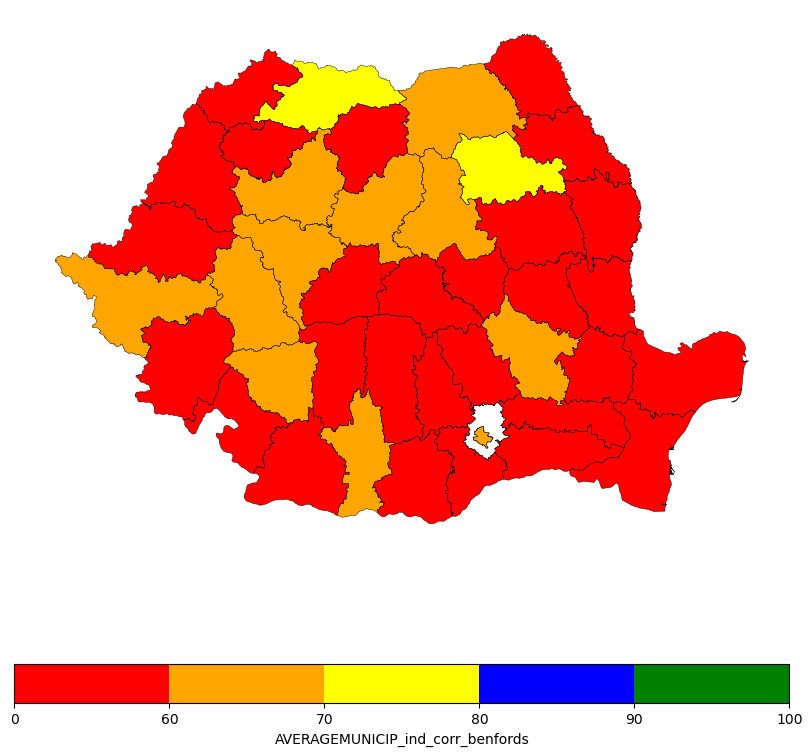

In [ ]:
colors = ['red', 'orange', 'yellow', 'blue', 'green']
boundaries = [0, 60, 70, 80, 90, 100]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf_1.boundary.plot(ax=ax, linewidth=0.3, color='black')
merged_1.plot(column='AVERAGEMUNICIP_ind_corr_dec_period',  ax=ax, cmap=cmap, norm=norm)
ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # No data for colorbar
cbar = fig.colorbar(sm, ax=ax, ticks=boundaries, orientation='horizontal')
cbar.set_label('AVERAGEMUNICIP_ind_corr_benfords')

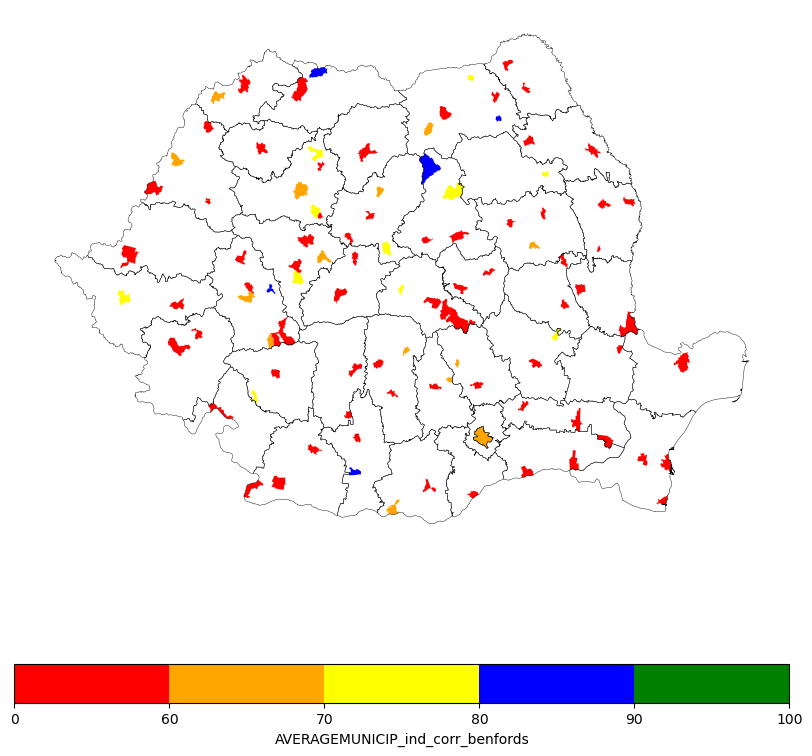

In [189]:
colors = ['red', 'orange', 'yellow', 'blue', 'green']
boundaries = [0, 60, 70, 80, 90, 100]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf_1.boundary.plot(ax=ax, linewidth=0.3, color='black')
merged_gdf.plot(column='AVERAGEMUNICIP_ind_corr_dec_period',  ax=ax, cmap=cmap, norm=norm)
ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # No data for colorbar
cbar = fig.colorbar(sm, ax=ax, ticks=boundaries, orientation='horizontal')
cbar.set_label('AVERAGEMUNICIP_ind_corr_benfords')